In [1]:
import torch
from pathlib import Path
import preprocess_data as ppd
from process_session import session as ps
import process_probe as pp
import numpy as np
from preprocess_data import *
import models as models
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
import pandas as pd
import sys
import multiprocessing 
import os
from process_attribution import *

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
df = pd.read_csv('units_info.csv')
print(df.head())

      unit_id  session_id                                       genotype  \
0  1179685687  1047969464  Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt   
1  1179685618  1047969464  Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt   
2  1179685304  1047969464  Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt   
3  1179685455  1047969464  Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt   
4  1179684888  1047969464  Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt   

   optotagged  cluster_id  pyr  sst  vip  
0           0           0    1    0    0  
1           0           0    1    0    0  
2           0           0    1    0    0  
3           0           4    0    0    0  
4           0           0    0    0    0  


In [2]:
# Session obj contains stimulus, channel, and unit information
output_dir  = r'Y:\buzsakilab\Buzsakilabspace\LabShare\NoamNitzan\Open_Access\Allen_2022'
session_id  = 1119946360
session_obj = ps(session_id, df, output_dir)

ecephys_session_1119946360.nwb: 100%|██████████| 3.65G/3.65G [27:15<00:00, 2.23MMB/s]    


In [3]:
# hyperparameters
input_size = len(session_obj.units)
hidden_size = 50 # 
num_layers = 1
seqlength = 750
num_epochs = 15 # 
bands = [(0.5, 4), (4, 8), (8, 12), (12, 25), (25, 50), (50, 100), (100, 200), (200, 400)]
criterion  = torch.nn.MSELoss()
batch_size = 32

In [4]:
# Spikes obj contains Spike matrix
bin_size=0.004
spikes_obj = ppd.pre_process_spikes(session_obj.units, session_obj.spike_times, bin_size=bin_size, sigma=3)
spikes_obj.getSpkMat(session_obj.active_times[0], session_obj.active_times[1])
spikes_obj.truncate(seqlength)
spikes_obj.convolve_with_gaussian()
spikes_obj.zscore()

100%|██████████| 1363/1363 [02:12<00:00, 10.30it/s]


In [5]:
# Probe obj contains LFP data
# Getting LFP  for active trials
lfp_obj = ppd.pre_process_lfp(session_id, session_obj.channels, session_obj.active_times[0],
                              session_obj.active_times[1], output_dir) 
lfp_obj.filter_lfp()
lfp_obj.downsample_lfp(5) # Downsample by 5
lfp_obj.truncate(seqlength) # Downsample by 5
lfp_obj.align_lfp(spikes_obj.spkMat.shape[0])
num_channels = len(lfp_obj.channels)

100%|██████████| 8/8 [04:13<00:00, 31.63s/it]


In [6]:
# get spontaneous data
spikes_obj_spont = ppd.pre_process_spikes(session_obj.units, session_obj.spike_times, bin_size=bin_size, sigma=3)
spikes_obj_spont.getSpkMat(session_obj.spontaneous_times[0], session_obj.spontaneous_times[1])
spikes_obj_spont.truncate(seqlength)
spikes_obj_spont.convolve_with_gaussian()
spikes_obj_spont.zscore()

lfp_obj_spont = ppd.pre_process_lfp(session_id, session_obj.channels, session_obj.spontaneous_times[0],
                              session_obj.spontaneous_times[1], output_dir) 
lfp_obj_spont.filter_lfp()
lfp_obj_spont.downsample_lfp(5) # Downsample by 5
lfp_obj_spont.truncate(seqlength) # Downsample by 5
lfp_obj_spont.align_lfp(spikes_obj_spont.spkMat.shape[0])

# get passive data
spikes_obj_passive = ppd.pre_process_spikes(session_obj.units, session_obj.spike_times, bin_size=bin_size, sigma=3)
spikes_obj_passive.getSpkMat(session_obj.passive_times[0], session_obj.passive_times[1])
spikes_obj_passive.truncate(seqlength)
spikes_obj_passive.convolve_with_gaussian()
spikes_obj_passive.zscore()

lfp_obj_passive = ppd.pre_process_lfp(session_id, session_obj.channels, session_obj.passive_times[0],
                                session_obj.passive_times[1], output_dir)
lfp_obj_passive.filter_lfp()
lfp_obj_passive.downsample_lfp(5) # Downsample by 5
lfp_obj_passive.truncate(seqlength) # Downsample by 5
lfp_obj_passive.align_lfp(spikes_obj_passive.spkMat.shape[0])

100%|██████████| 8/8 [04:07<00:00, 30.90s/it]


In [7]:
chani = 5 # deep layer
bandi = 0 # broadband

X_train, X_test, y_train, y_test = chunk_and_reshape(spikes_obj.spkMat, lfp_obj.lfpMat[:,chani,bandi] , seqlength, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

train_dataloader, test_dataloader = get_data_loaders(X_train, X_test, y_train, y_test, batch_size , device)

test_spikes = torch.cat([X for X, _ in test_dataloader], dim=0)
test_lfp = torch.cat([y for _, y in test_dataloader], dim=0)

# reshape to time X features
test_spikes = test_spikes.reshape(test_spikes.shape[0] * test_spikes.shape[1], test_spikes.shape[2])
test_lfp = test_lfp.reshape(test_lfp.shape[0] * test_lfp.shape[1])

(960, 750, 1363) (241, 750, 1363) (960, 750, 1) (241, 750, 1)


## compare models

In [8]:
# linear regression model 
linear_model = models.LinearRegressionModel(input_size)
ln_train_loss, ln_test_loss = linear_model.train(train_dataloader,
                                               test_dataloader, numepochs=1)

print(f'Linear regression train loss: {ln_train_loss[-1]:.4f}')
print(f'Linear regression test loss: {ln_test_loss[-1]:.4f}')

Linear regression train loss: 0.2350
Linear regression test loss: 0.6581


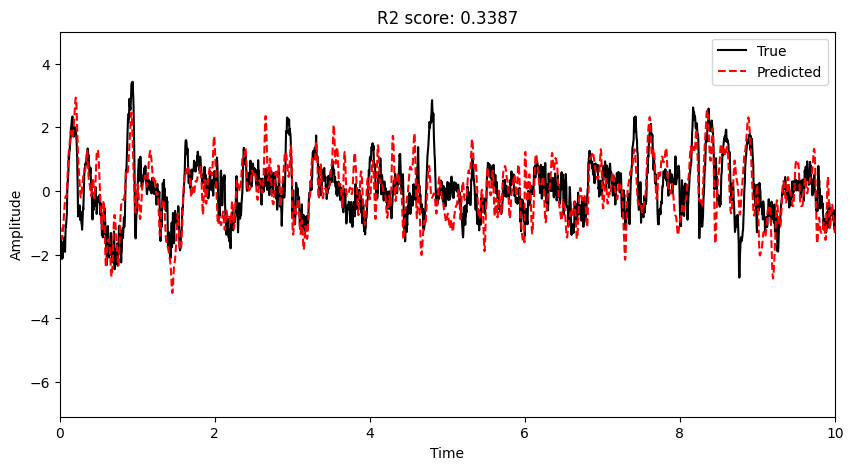

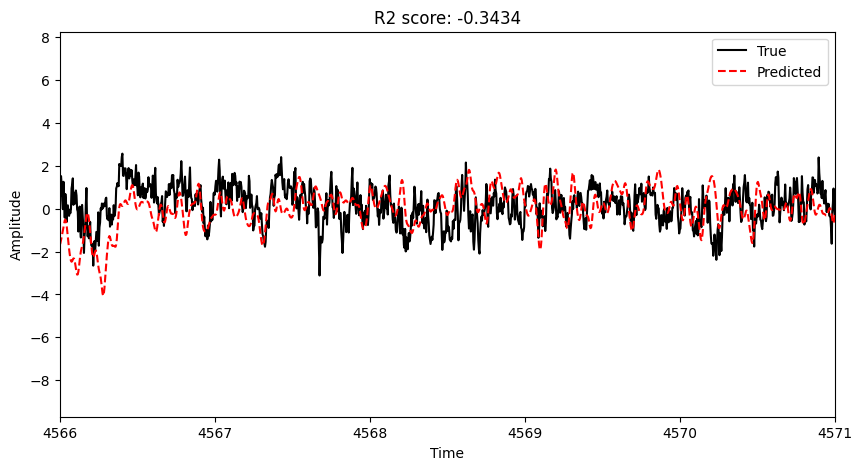

In [9]:
# 3. Evaluate the linear model
y_hat_test = linear_model.evaluate(test_spikes)

time_test = np.linspace(0, test_lfp.shape[0] * bin_size , test_lfp.shape[0])

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(time_test, test_lfp.cpu().numpy(), 'k', label='True')
ax.plot(time_test, y_hat_test, '--r', label='Predicted')
ax.set_xlim([0, 10])
ax.set_xlabel('Time')
ax.set_ylabel('Amplitude')
ax.set_title(f'R2 score: {r2_score(test_lfp.cpu().numpy(), y_hat_test):.4f}')
ax.legend()
plt.show()

y_hat_spont = linear_model.evaluate(torch.tensor(spikes_obj_spont.spkMat).float())

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(spikes_obj_spont.timestamps, lfp_obj_spont.lfpMat[:,chani,bandi], 'k', label='True')
ax.plot(spikes_obj_spont.timestamps, y_hat_spont, '--r', label='Predicted')
ax.set_xlim([spikes_obj_spont.timestamps[0], spikes_obj_spont.timestamps[0]+5])
ax.set_xlabel('Time')
ax.set_ylabel('Amplitude')
ax.set_title(f'R2 score: {r2_score(lfp_obj_spont.lfpMat[:,chani,bandi], y_hat_spont):.4f}')
ax.legend()
plt.show()


In [10]:
# LSTM model

lstm_model = models.process_model(models.LSTMnet(input_size, hidden_size, num_layers,seqlength), criterion, device)
lstm_train_loss, lstm_test_loss = lstm_model.train(train_dataloader,
                                        test_dataloader , num_epochs)

print(f'LSTM  train loss: {lstm_train_loss[-1]:.4f}')
print(f'LSTM  test loss: {lstm_test_loss[-1]:.4f}')

LSTM  train loss: 0.0936
LSTM  test loss: 0.2815


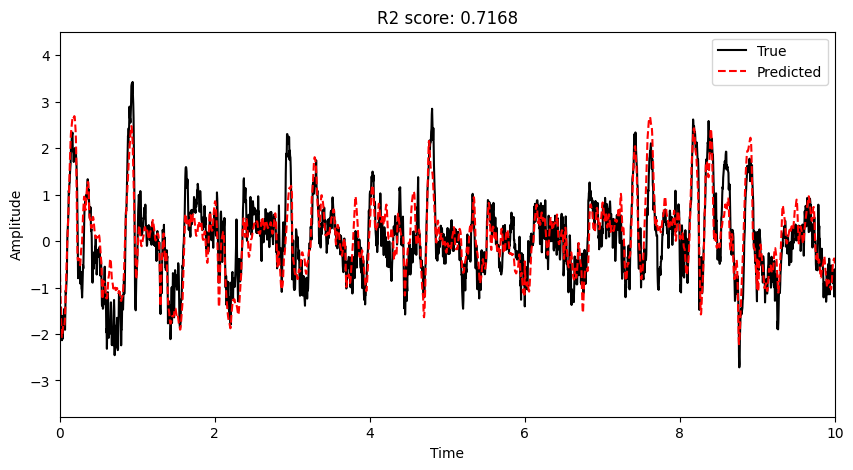

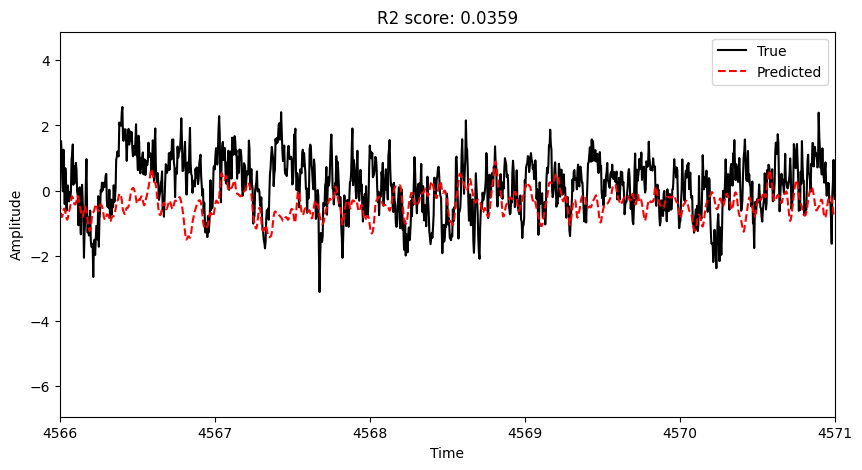

In [11]:
y_hat_test = lstm_model.evaluate(test_dataloader.dataset.tensors[0])

time = np.linspace(0, test_lfp.shape[0] * bin_size , test_lfp.shape[0])

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(time, test_lfp.cpu().numpy(), 'k', label='True')
ax.plot(time, y_hat_test, '--r', label='Predicted')
ax.set_xlim([0, 10])
ax.set_xlabel('Time')
ax.set_ylabel('Amplitude')
ax.set_title(f'R2 score: {r2_score(test_lfp.cpu().numpy(), y_hat_test):.4f}')
ax.legend()
plt.show()

y_hat_spont = lstm_model.evaluate(torch.tensor(spikes_obj_spont.spkMat).float().to(device))

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(spikes_obj_spont.timestamps, lfp_obj_spont.lfpMat[:,chani,bandi], 'k', label='True')
ax.plot(spikes_obj_spont.timestamps, y_hat_spont, '--r', label='Predicted')
ax.set_xlim([spikes_obj_spont.timestamps[0], spikes_obj_spont.timestamps[0]+5])
ax.set_xlabel('Time')
ax.set_ylabel('Amplitude')
ax.set_title(f'R2 score: {r2_score(lfp_obj_spont.lfpMat[:,chani,bandi], y_hat_spont):.4f}')
ax.legend()
plt.show()

In [12]:
# transformer model
num_epochs_transformer = 10
transformer_model = models.process_model(models.SpikingTransformer(input_size=input_size, seqlength=seqlength,
                                                                   embedding_dim = 64, num_heads = 8, 
                                                                   dropout=0.05), criterion, device)

transformer_train_loss, transformer_test_loss = transformer_model.train(train_dataloader,
                                        test_dataloader , num_epochs_transformer)

print(f'transformer  train loss: {transformer_train_loss[-1]:.4f}')
print(f'transformer  test loss:  {transformer_test_loss[-1]:.4f}')

transformer  train loss: 0.2486
transformer  test loss:  0.2823


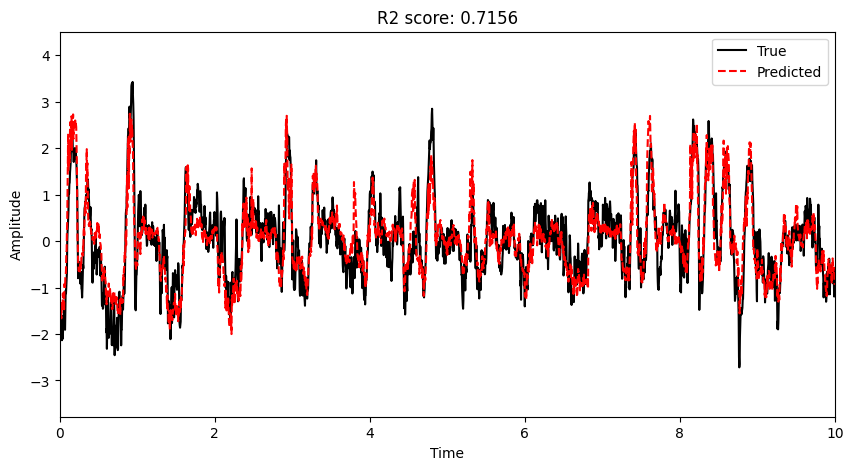

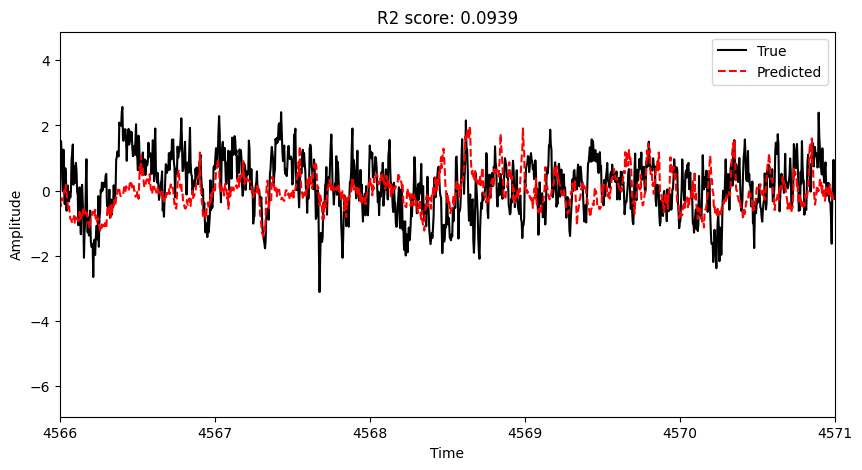

In [13]:
y_hat_test = transformer_model.evaluate(test_spikes)

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(time, test_lfp.cpu().numpy(), 'k', label='True')
ax.plot(time, y_hat_test, '--r', label='Predicted')
ax.set_xlim([0, 10])
ax.set_xlabel('Time')
ax.set_ylabel('Amplitude')
ax.set_title(f'R2 score: {r2_score(test_lfp.cpu().numpy(), y_hat_test):.4f}')
ax.legend()
plt.show()

y_hat_spont = transformer_model.evaluate(torch.tensor(spikes_obj_spont.spkMat).float())

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(spikes_obj_spont.timestamps, lfp_obj_spont.lfpMat[:,chani,bandi], 'k', label='True')
ax.plot(spikes_obj_spont.timestamps, y_hat_spont, '--r', label='Predicted')
ax.set_xlim([spikes_obj_spont.timestamps[0], spikes_obj_spont.timestamps[0]+5])
ax.set_xlabel('Time')
ax.set_ylabel('Amplitude')
ax.set_title(f'R2 score: {r2_score(lfp_obj_spont.lfpMat[:,chani,bandi], y_hat_spont):.4f}')
ax.legend()
plt.show()

## run the LSTM model on all channels and bands

In [14]:
lossesTrain, lossesTest = (np.zeros((len(lfp_obj.channels), num_epochs, len(bands)+1)) for _ in range(2))
R2_train, R2_test       = (np.zeros((len(lfp_obj.channels), len(bands)+1)) for _ in range(2))

# initialize dictionary to store trained models 
all_models = {}

for bandi in range(len(bands)+1):
    sys.stdout.write('\r' + 'Working on band ' + str(bandi + 1) + ' out of ' + str(len(bands)+1) + '\n')
    
    X_train, X_test, y_train, y_test  = chunk_and_reshape(spikes_obj.spkMat, lfp_obj.lfpMat[:,:,bandi] , seqlength, test_size=0.2, random_state=42)

    for chani in range(len(lfp_obj.channels)):
        sys.stdout.write('\t' + 'Training model for channel ' + str(chani+1) + ' out of ' + str(lfp_obj.lfpMat.shape[1]) + '\n')
        
        train_dataloader, test_dataloader = get_data_loaders(X_train, X_test, y_train[:,:,chani], y_test[:,:,chani], batch_size , device)
        
        model = models.process_model(models.LSTMnet(input_size, hidden_size, num_layers,seqlength), criterion, device)
        
        train_loss, test_loss = model.train(train_dataloader,
                                        test_dataloader , num_epochs)
        
        yHat = model.evaluate(test_dataloader.dataset.tensors[0])
        R2_test[chani, bandi] = r2_score(test_dataloader.dataset.tensors[1].cpu().numpy().reshape(-1,1), yHat)
        yHat = model.evaluate(train_dataloader.dataset.tensors[0])
        R2_train[chani, bandi] = r2_score(train_dataloader.dataset.tensors[1].cpu().numpy().reshape(-1,1), yHat)
        
        lossesTrain[chani,:, bandi] = train_loss
        lossesTest[chani,:, bandi] = test_loss
        
        all_models[chani, bandi] = model


Working on band 1 out of 9
	Training model for channel 1 out of 22
	Training model for channel 2 out of 22
	Training model for channel 3 out of 22
	Training model for channel 4 out of 22
	Training model for channel 5 out of 22
	Training model for channel 6 out of 22
	Training model for channel 7 out of 22
	Training model for channel 8 out of 22
	Training model for channel 9 out of 22
	Training model for channel 10 out of 22
	Training model for channel 11 out of 22
	Training model for channel 12 out of 22
	Training model for channel 13 out of 22
	Training model for channel 14 out of 22
	Training model for channel 15 out of 22
	Training model for channel 16 out of 22
	Training model for channel 17 out of 22
	Training model for channel 18 out of 22
	Training model for channel 19 out of 22
	Training model for channel 20 out of 22
	Training model for channel 21 out of 22
	Training model for channel 22 out of 22
Working on band 2 out of 9
	Training model for channel 1 out of 22
	Training mod

In [15]:
# get model predictions for the entire active session
yHat_active = np.zeros((lfp_obj.lfpMat.shape[0], lfp_obj.lfpMat.shape[1], len(bands)+1))
for chani in range(len(lfp_obj.channels)):
    for bandi in range(len(bands)+1):
        yHat_active[:,chani,bandi] = all_models[chani, bandi].evaluate(torch.tensor(spikes_obj.spkMat).float().to(device))

RuntimeError: [enforce fail at alloc_cpu.cpp:114] data. DefaultCPUAllocator: not enough memory: you tried to allocate 4910889000 bytes.

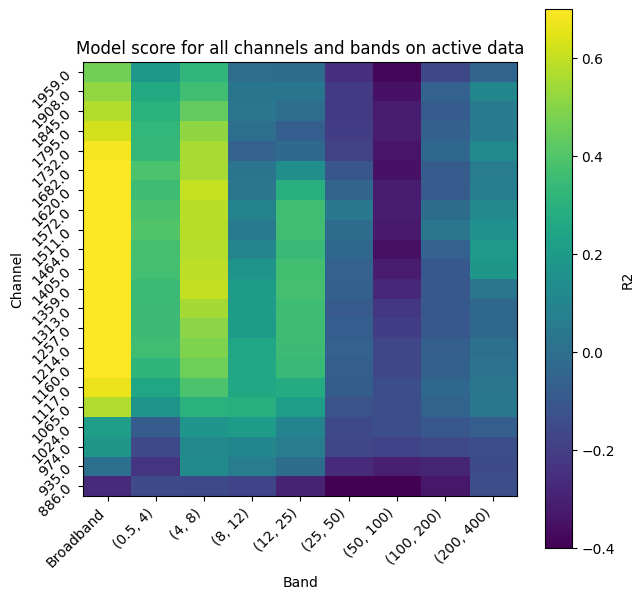

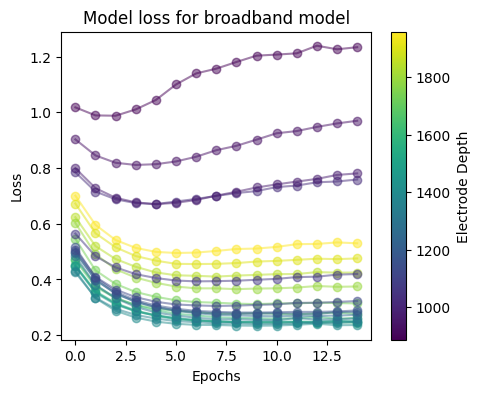

In [17]:
import importlib
import plots
importlib.reload(plots)
from plots import * 

plot_r2(R2_test, lfp_obj.channels, bands)
plot_all_channel_loss(lfp_obj.channels, bands, 0, lossesTest)
# plot_lfp_prediction(lfp_obj.lfpMat, yHat_active, 5, bands, start_time = 20, end_time = 30)
# plot_abs_error_change(lfp_obj.lfpMat, yHat_active, session_obj, spikes_obj.timestamps, 5, bands)
# plot_psd(lfp_obj.lfpMat, yHat_active, 5)

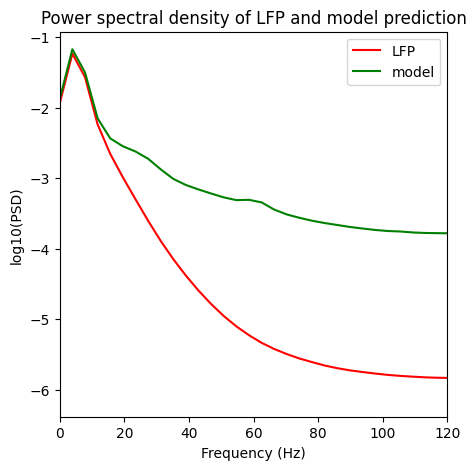

In [100]:
plot_psd(lfp_obj.lfpMat, yHat_active, 5)

In [62]:
# save the models 
output_dir = Path(output_dir)
output_dir_models = output_dir / 'models' / str(session_id)
os.makedirs(output_dir_models, exist_ok=True)

for idx in range(len(all_models.keys())):
    chan = list(all_models.keys())[idx][0]
    band = list(all_models.keys())[idx][1]
    filename = output_dir_models / f'lstm_model_chan{chan}_band{band}.pt'
    torch.save(all_models[chan, band].model.state_dict(), filename)

In [270]:
# calculate attribution scores from passive data
attr_dur = 720
mean_attribution = np.zeros((num_channels, len(bands)+1 , spikes_obj.spkMat.shape[1]))

X_attr = torch.tensor(spikes_obj_passive.spkMat[:int(attr_dur/bin_size),:]).float().to(device)
num_trials = int(int(attr_dur/bin_size)/seqlength)
X_attr = X_attr.reshape(num_trials, seqlength, X_attr.shape[1])

for chani in range(lfp_obj.lfpMat.shape[1]):
    for bandi in range(lfp_obj.lfpMat.shape[2]):
        model = all_models[chani, bandi]
        ig = IntegratedGradients(model.model.train().to(device))        
        attr = calculate_attr(X_attr , ig).squeeze(1).cpu().numpy()
        attr = attr.reshape(attr.shape[0] * attr.shape[1], attr.shape[2])
        filename = output_dir_models / 'attrs' / f'attribution_scores_chan{chani}_band{bandi}.npz'
        mean_attribution[chani, bandi, :] = np.mean(attr, axis=0)
        # np.save(attr.astype('float32'), filename, allow_pickle=True)
        np.savez_compressed(filename, attr=attr.astype('float32'))
        

100%|██████████| 240/240 [00:03<00:00, 72.89it/s]


In [ ]:
# for each area, calculate the mean attribution across all channels and bands
areas = sorted(session_obj.units['structure_acronym'].unique())
attributions_areas = np.zeros((len(areas), len(bands)+1, num_channels))
for areai, area in enumerate(areas):
    ind = ([session_obj.units['structure_acronym'] == area])[0]
    for chani in range(num_channels):
        for bandi in range(len(bands)+1):
            attributions_areas[areai, bandi, chani] = np.mean(mean_attribution[chani, bandi, ind])
            
# for each cluster, calculate the mean attribution across all channels and bands            
cluster_id = {1:[], 2:[], 3:[], 4:[], 5:[]}
for i in range(1,6):
    cluster_id[i] = list(df.unit_id[df['cluster_id'] == i])
    
mean_attr_clusters = np.zeros((len(df['cluster_id'].unique()), len(bands)+1, num_channels))

for clusteri in range(1,6):
    for bandi in range(len(bands)+1):
        for chani in range(num_channels):
            ind = session_obj.units.index.isin(cluster_id[clusteri])
            mean_attr_clusters[clusteri, bandi, chani] = np.mean(mean_attribution[chani, bandi, ind])

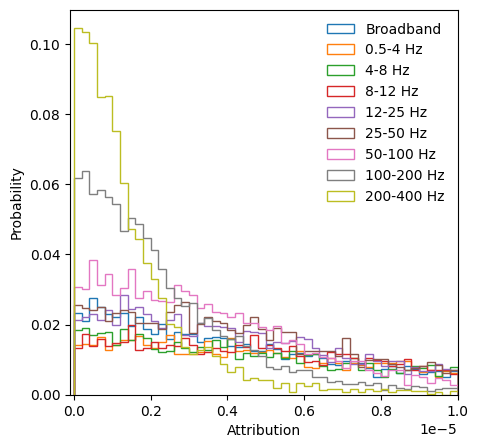

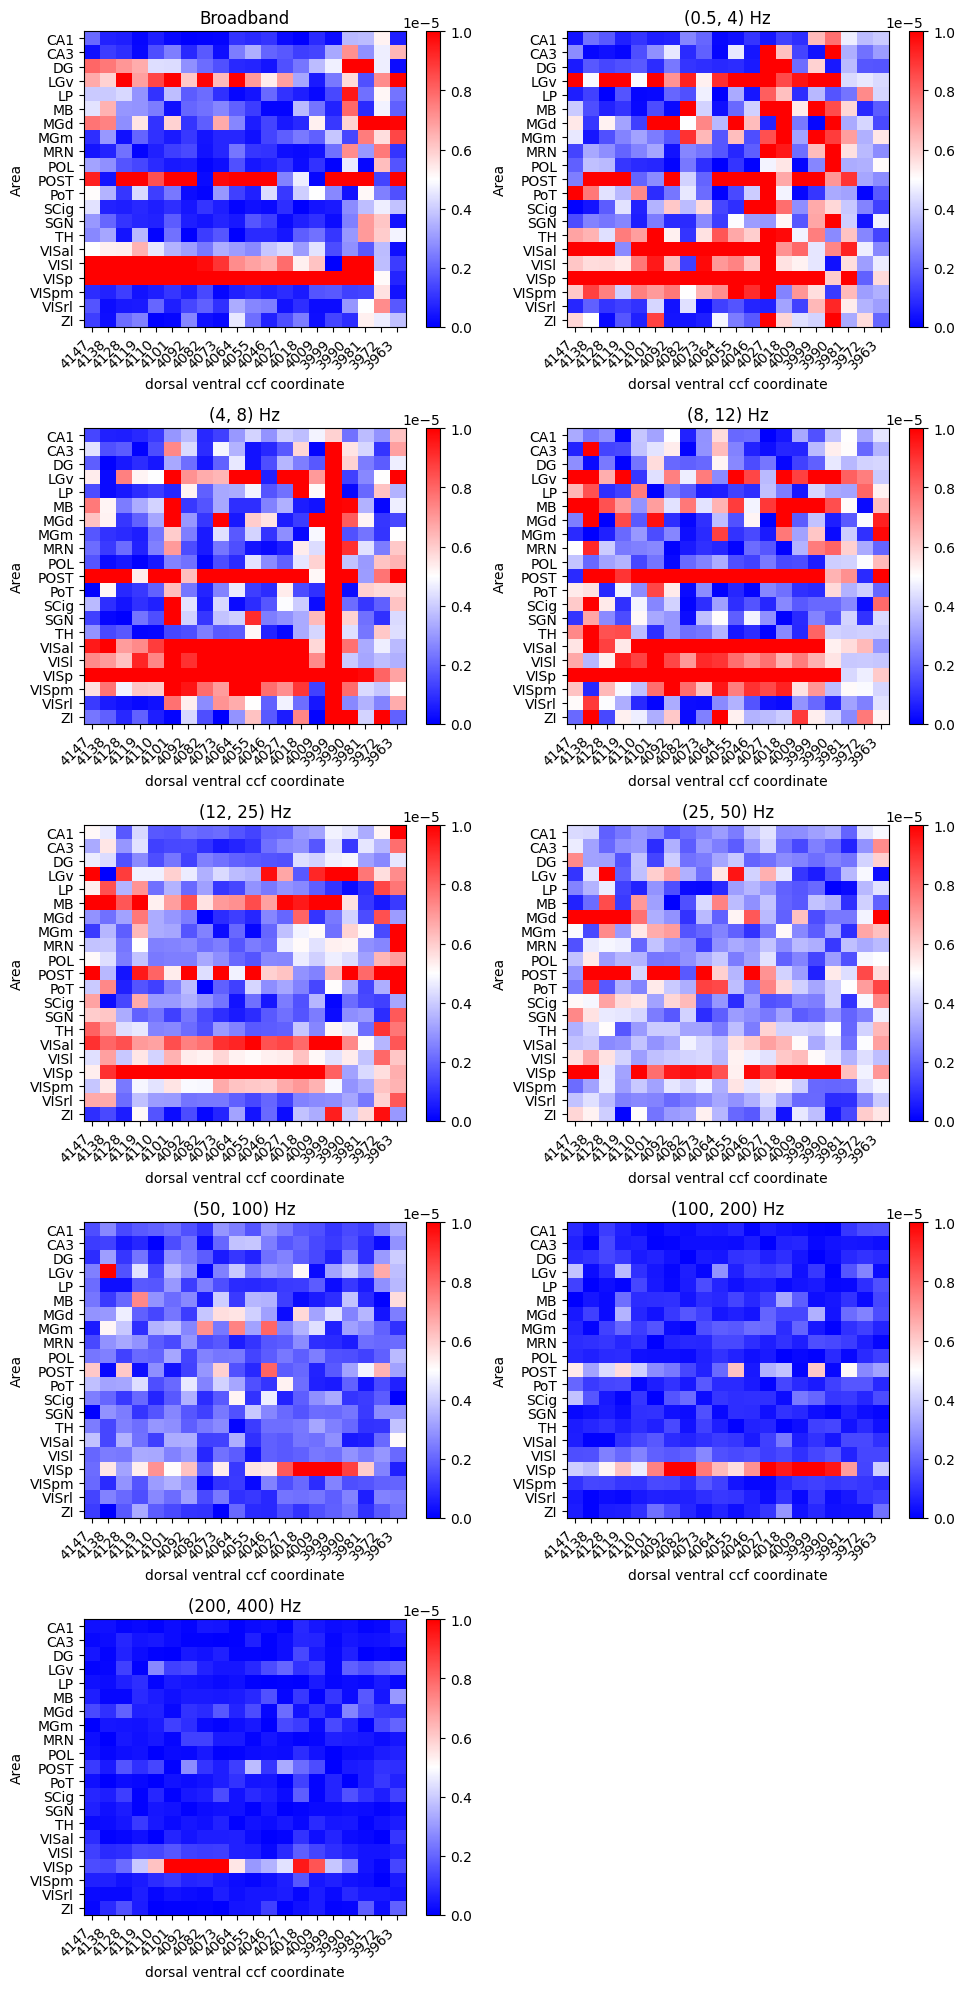

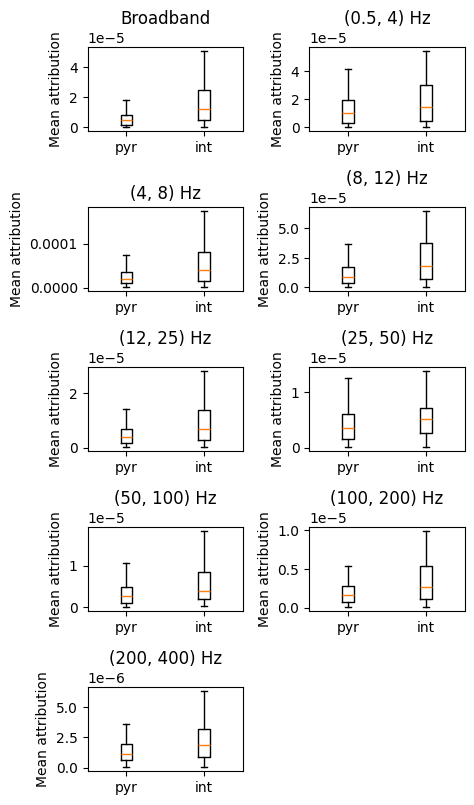

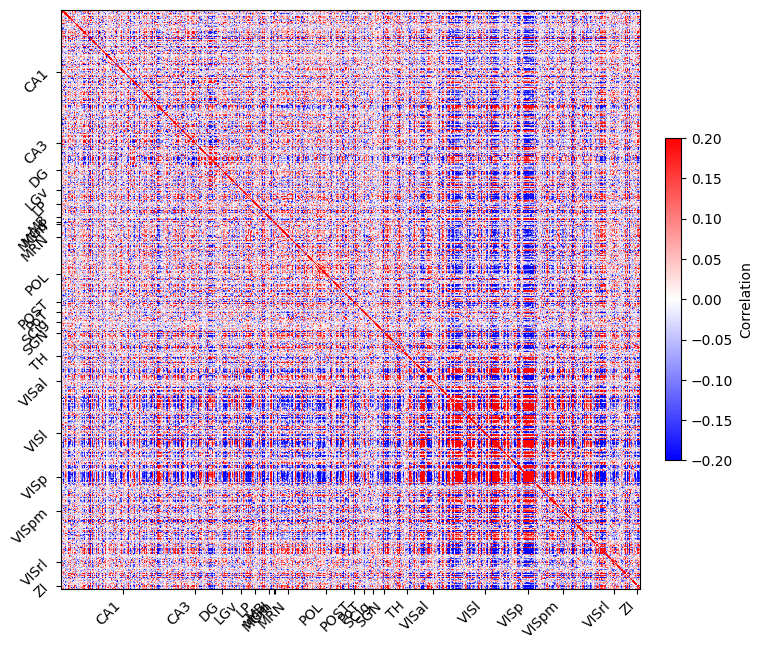

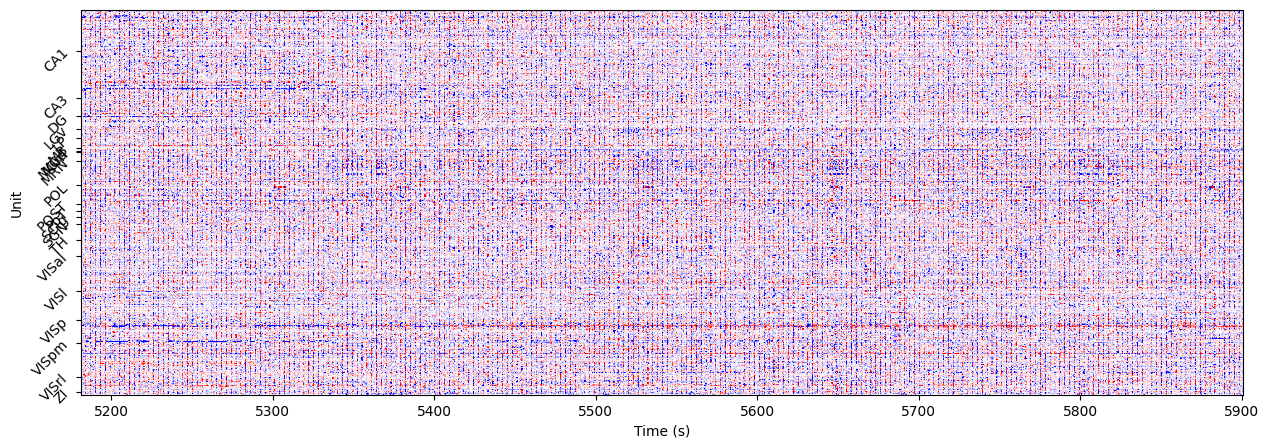

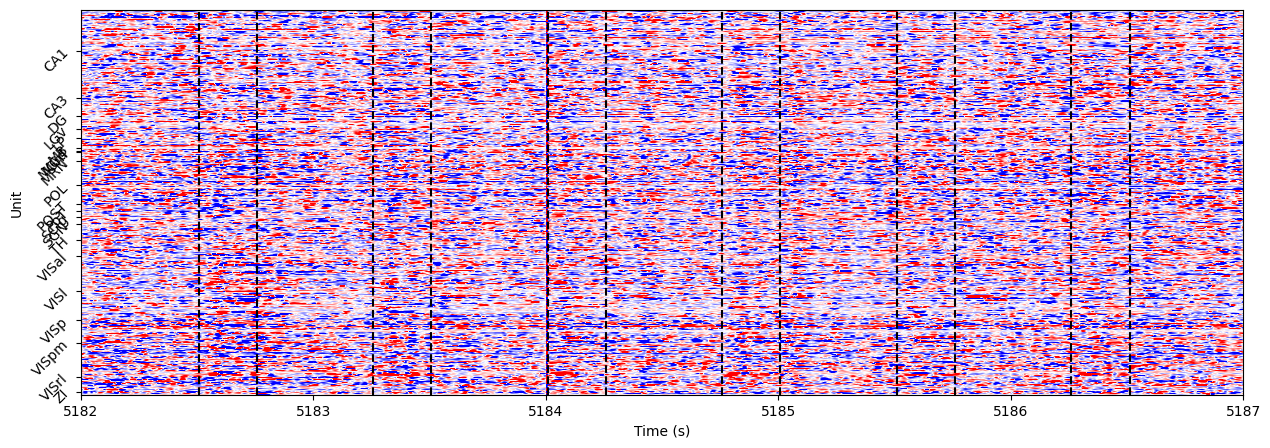

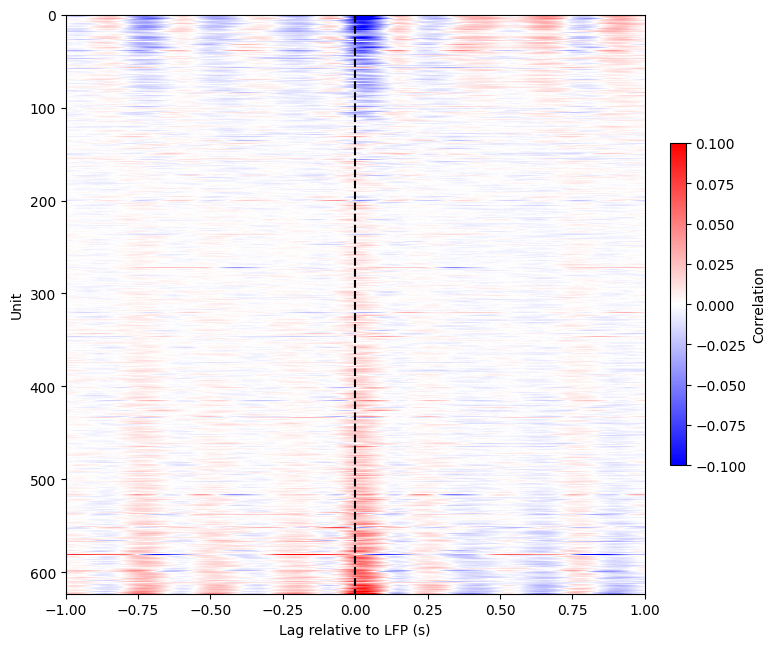

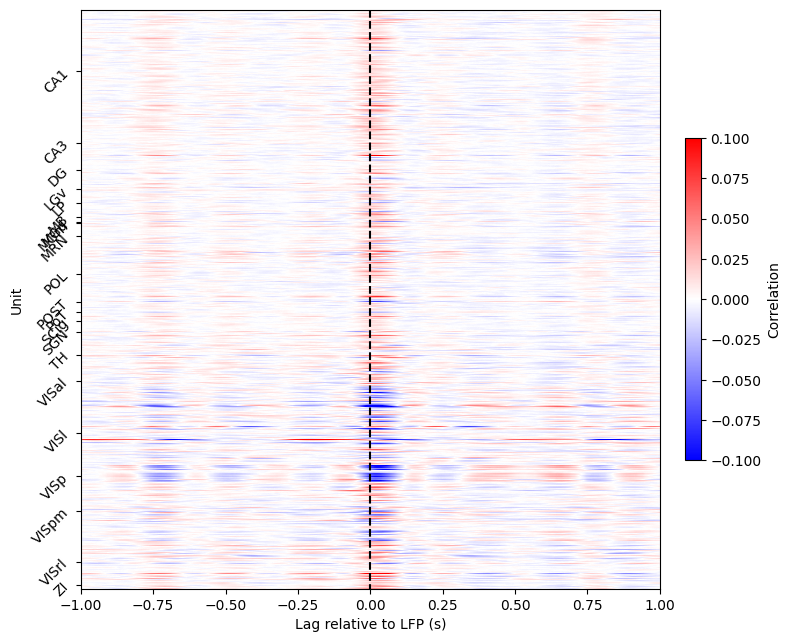

In [416]:
importlib.reload(plots)
from plots import *

plot_attr_density_plots(mean_attribution, session_obj, bands, 'VIS')
plot_mean_attr_areas(attributions_areas, lfp_obj_passive, session_obj, bands)
plot_mean_attr_pyr_int(mean_attribution, session_obj, 'VIS', df, bands, 5)
plot_mean_attr_clusters(mean_attr_clusters, lfp_obj_passive , bands)

# plot broadband attributions 
chani = 5
broadband_attr = np.load(output_dir_models / 'attrs' / f'attribution_scores_chan{chani}_band{0}.npz')
broadband_attr = broadband_attr['attr']

plot_attr_corrmat(broadband_attr,session_obj)
plot_attr_matrix(attr, spikes_obj_passive.timestamps[:int(attr_dur/bin_size)], 
                 session_obj, [spikes_obj_passive.timestamps[0], spikes_obj_passive.timestamps[0] + attr_dur])
plot_attr_matrix(attr, spikes_obj_passive.timestamps[:int(attr_dur/bin_size)], 
                 session_obj, [5182, 5187], plot_stim = True)

plot_attr_lfp_corr(broadband_attr, lfp_obj_passive.lfpMat[:int(attr_dur/bin_size),chani,0], session_obj) # max sorting
plot_attr_lfp_corr(broadband_attr, lfp_obj_passive.lfpMat[:int(attr_dur/bin_size),chani,0], session_obj, sorting = "areas") # areas


In [ ]:
# for each neuron, calculate the correlation between the attribution scores and the firing rate
unit_attr_fr_corr = np.zeros( (input_size ,num_channels, len(bands)+1))

for bandi in range(len(bands)+1):
    for chani in range(num_channels):
        filename = output_dir_models / 'attrs' / f'attribution_scores_chan{chani}_band{bandi}.npz'
        attr = np.load(filename)['attr']
        mean1 = np.mean(attr.T, axis=1, keepdims=True)
        mean2 = np.mean(spikes_obj_passive.spkMat[:int(attr_dur/bin_size),:].T, axis=1, keepdims=True)
        centered1 = attr.T - mean1
        centered2 = spikes_obj_passive.spkMat[:int(attr_dur/bin_size),:].T - mean2
        covariance = np.sum(centered1 * centered2, axis=1)
        std1 = np.sqrt(np.sum(centered1**2, axis=1))
        std2 = np.sqrt(np.sum(centered2**2, axis=1))
        unit_attr_fr_corr[:, chani, bandi] = covariance / (std1 * std2)
            

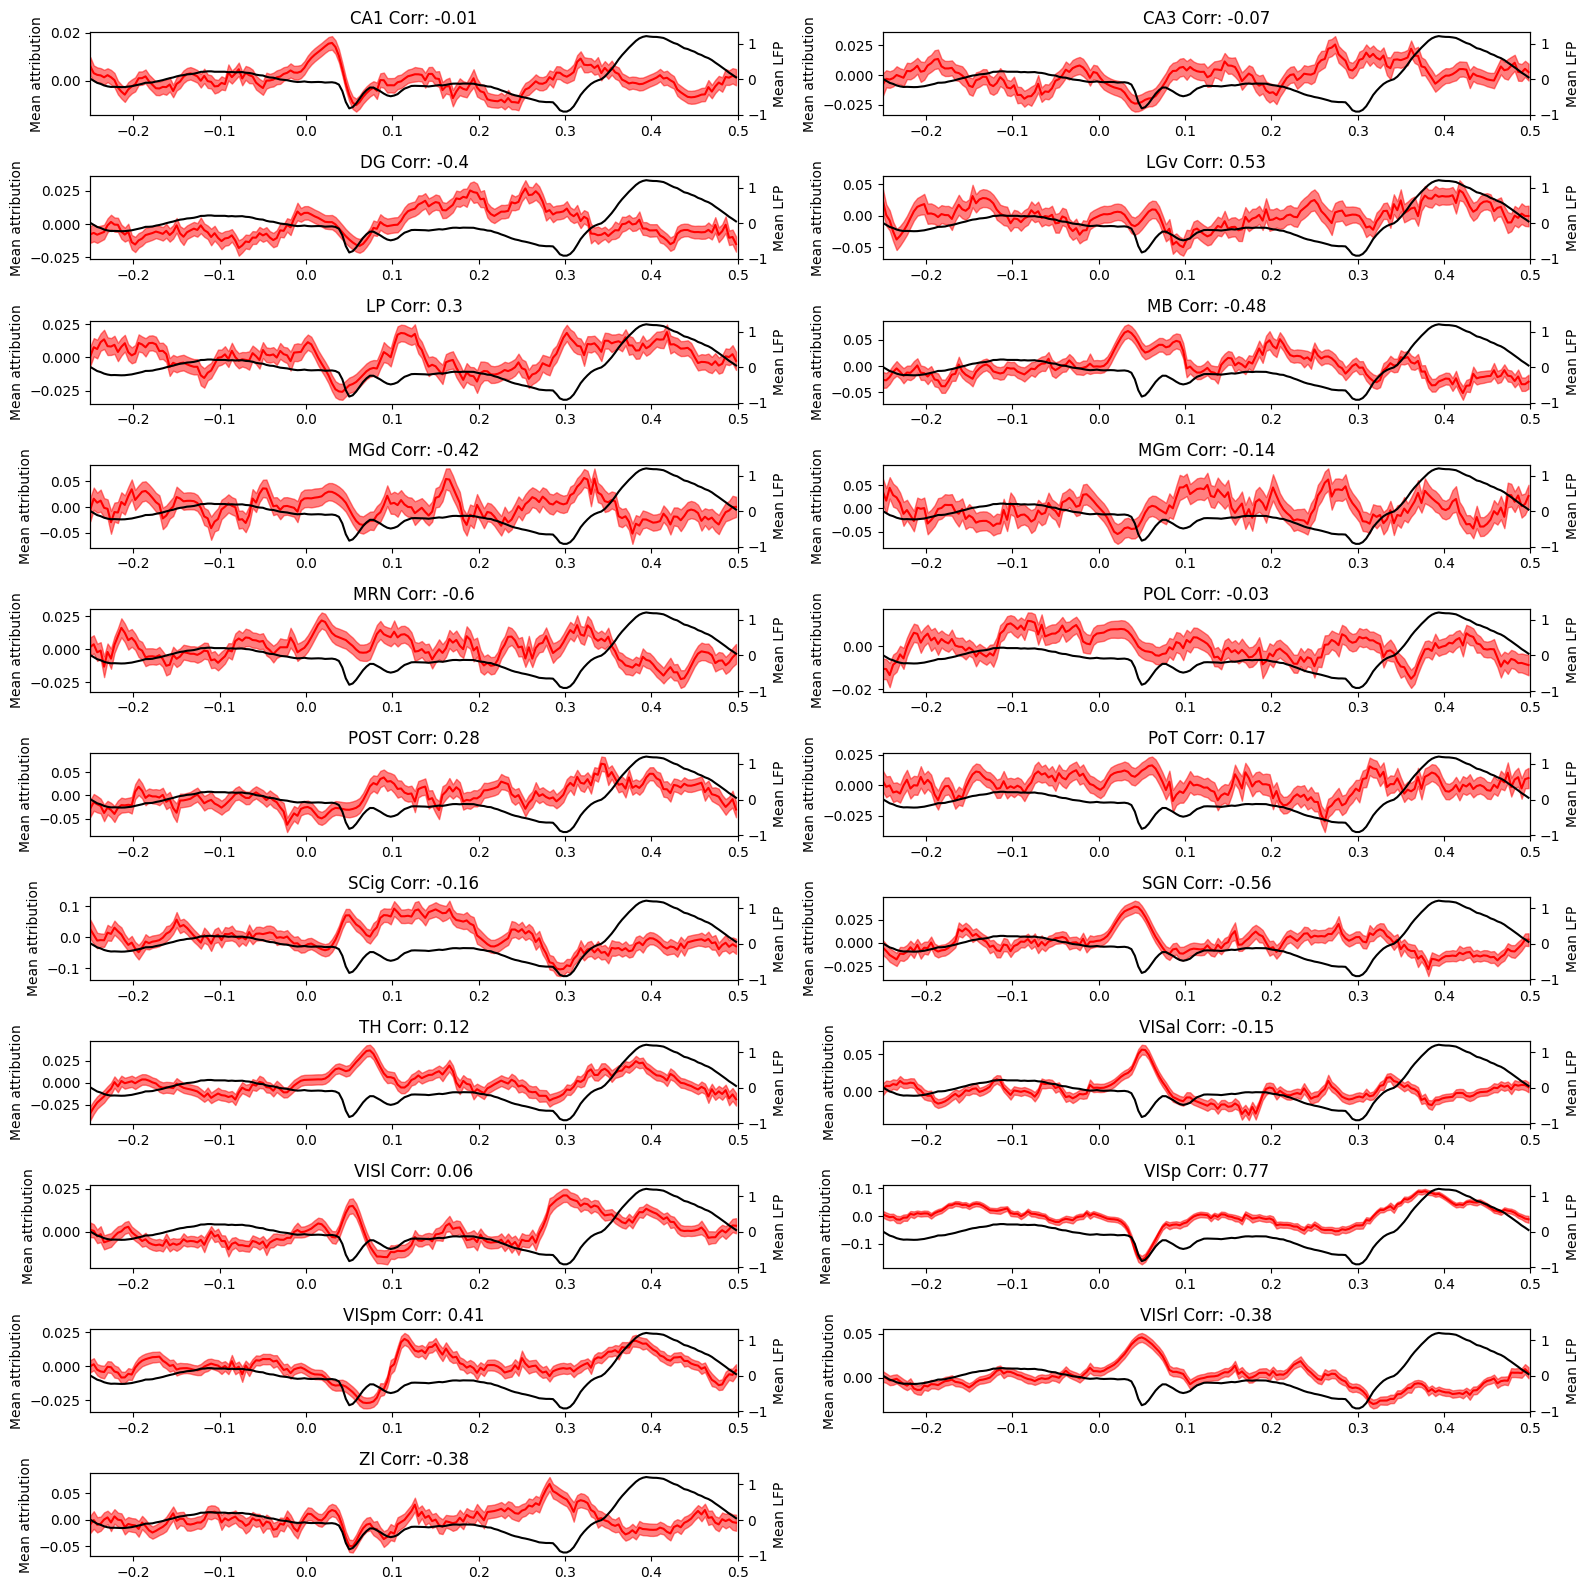

In [608]:
importlib.reload(plots)   
from plots import *
# plot_unit_attr_fr_corr(unit_attr_fr_corr, session_obj, bands)
attr_snippets, lfp_snippets, t = plot_peri_stim_attr(broadband_attr, lfp_obj_passive.lfpMat[:int(attr_dur/bin_size),5,0], session_obj,
                    spikes_obj_passive.timestamps[:int(attr_dur/bin_size)], [-.25, 0.5])

max val: 6.509204831672832e-05, min val: -5.233322735875845e-05
Max neuron: 35, Min neuron: 32


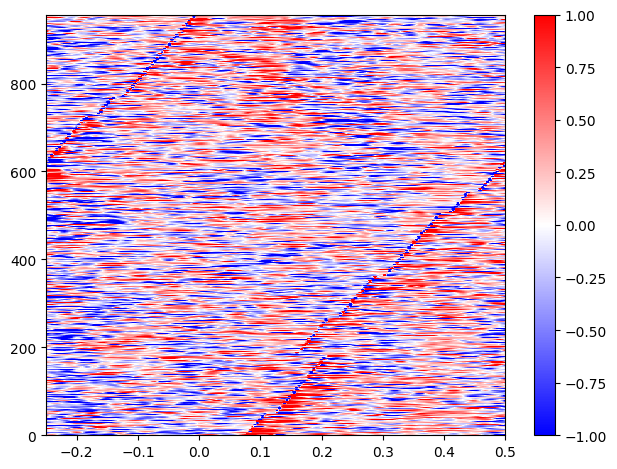

In [641]:
# find the neurons with the highest and lowest attribution scores 
# max_neuron = np.argmax(np.median(broadband_attr,axis=0)) # broadband channel 5
# min_neuron = np.argmin(np.median(broadband_attr,axis=0)) # broadband channel 5
# max_val = np.max(np.median(broadband_attr,axis=0))
# min_val = np.min(np.median(broadband_attr,axis=0))
# print(f'max val: {max_val}, min val: {min_val}')    
# print(f'Max neuron: {max_neuron}, Min neuron: {min_neuron}')

# win = [10, 20]

# fig, ax = plt.subplots(2, 1, figsize=(10, 5))
# ax[0].plot(spikes_obj_passive.timestamps[:int(attr_dur/bin_size)], 
#            zscore(spikes_obj_passive.spkMat[:int(attr_dur/bin_size),max_neuron]), 'k', label='firing rate')
# ax[0].plot(spikes_obj_passive.timestamps[:int(attr_dur/bin_size)],
#               zscore(broadband_attr[:,max_neuron]), 'r', label='attribution score')
# ax[0].set_xlim([spikes_obj_passive.timestamps[0]+win[0], spikes_obj_passive.timestamps[0]+win[1]])
# ax[0].set_ylim([-10, 10])
# ax[0].set_xlabel('Time')
# ax[0].set_ylabel('Amplitude')

# ax[1].plot(spikes_obj_passive.timestamps[:int(attr_dur/bin_size)], 
#            zscore(spikes_obj_passive.spkMat[:int(attr_dur/bin_size),min_neuron]), 'k', label='firing rate')
# ax[1].plot(spikes_obj_passive.timestamps[:int(attr_dur/bin_size)],
#               zscore(broadband_attr[:,min_neuron]), 'r', label='attribution score')
# ax[1].set_xlim([spikes_obj_passive.timestamps[0]+win[0], spikes_obj_passive.timestamps[0]+win[1]])
# ax[1].set_ylim([-10, 10])
# ax[1].set_xlabel('Time')
# ax[1].set_ylabel('Amplitude')

# plt.imshow(attr_snippets[:,:,max_neuron], aspect='auto', cmap='bwr', extent=[-0.25, 0.5, 0, attr_snippets.shape[0]],vmin=-1, vmax=1)
# plt.colorbar()
# plt.tight_layout()
# plt.show()

In [629]:
timestamps = spikes_obj_passive.timestamps[:int(attr_dur/bin_size)]
time_win = [-.25, 0.5]
t = np.arange(time_win[0], time_win[1], bin_size)

stim_st = session_obj.stimulus_presentation.start_time
stim_st = stim_st[((stim_st - np.abs(time_win[0])) > timestamps[0]) & ((stim_st + np.abs(time_win[1])) < timestamps[-1])]
stim_st = stim_st.values

areas = sorted(session_obj.units['structure_acronym'].unique())

attr_snippets = np.zeros((len(stim_st), len(t), broadband_attr.shape[1]))

for i in range(len(stim_st)):
    start = np.argmin(np.abs(timestamps - (stim_st[i]- np.abs(time_win[0])  )))
    attr_snippets[i,:,:] = broadband_attr[start:start+len(t),:]


In [637]:
len(t)

188

In [635]:
(stim_st[i]- np.abs(time_win[0])  )

5182.257727651676

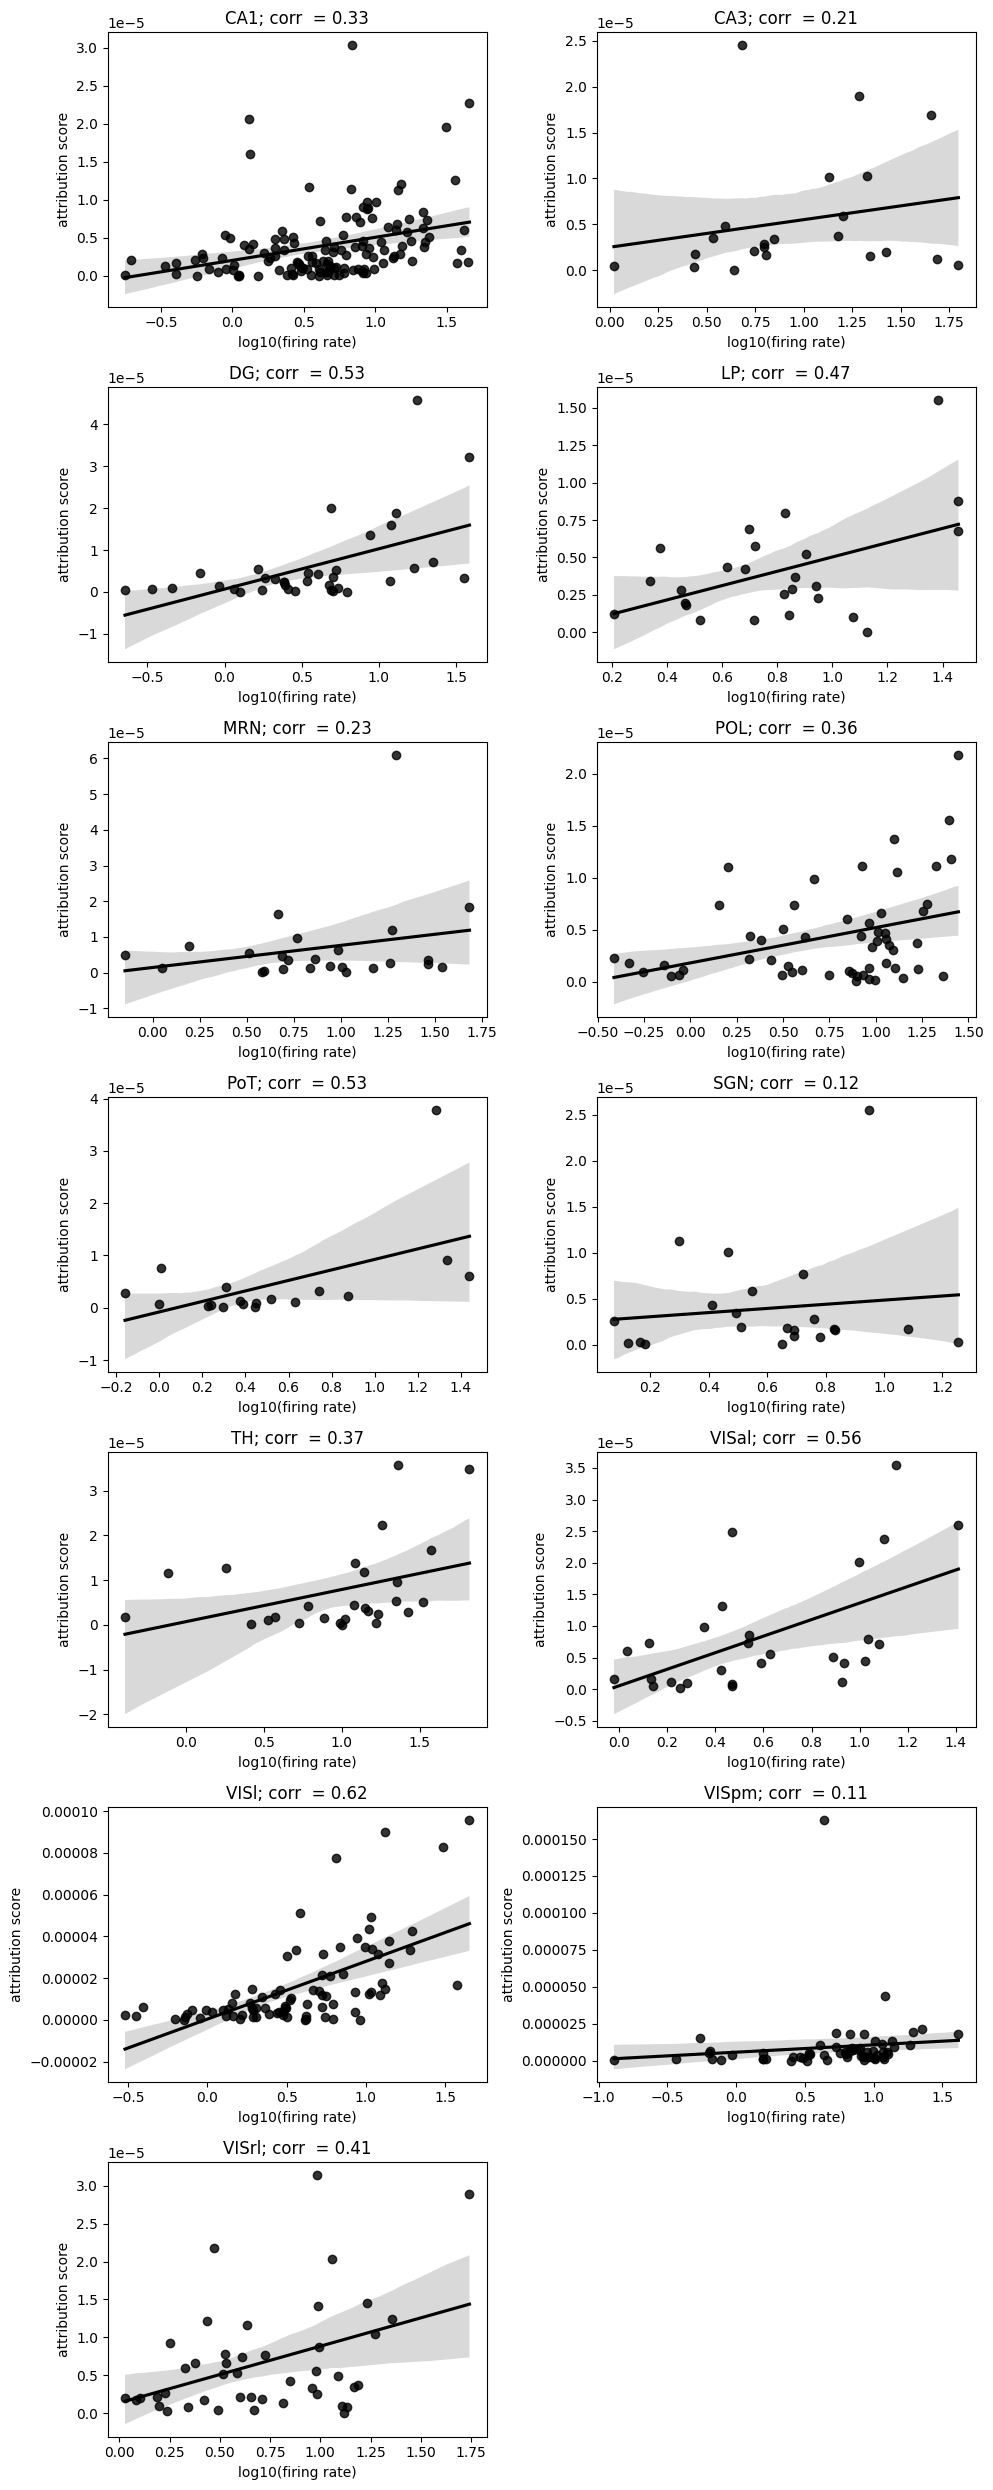

In [606]:
# correlation between the firing rate and the attribution score
import seaborn as sns

fr = session_obj.units['firing_rate']
areas = sorted(session_obj.units['structure_acronym'].unique())
area_counts = session_obj.units['structure_acronym'].value_counts()
areas = sorted(area_counts[area_counts > 10].index)

fig, ax = plt.subplots(np.ceil(len(areas)/2).astype(int), 2, figsize=(10, 25))
for areai, area in enumerate(areas):
    ind = ([session_obj.units['structure_acronym'] == area])[0]
    sns.regplot(x=np.log10(fr[ind]), y=np.abs(mean_attribution[5,0,ind]), ax=ax.flatten()[areai], color='k')
    ax.flatten()[areai].set_title(area)
    ax.flatten()[areai].set_xlabel('log10(firing rate)')
    ax.flatten()[areai].set_ylabel('attribution score')
    ax.flatten()[areai].set_title(f'{area}; corr  = {np.corrcoef(np.log10(fr[ind]), np.abs(mean_attribution[5,0,ind]))[0,1]:.2f}')

if len(areas) % 2 != 0:
       fig.delaxes(ax.flat[-1]) 
plt.tight_layout()
plt.show()


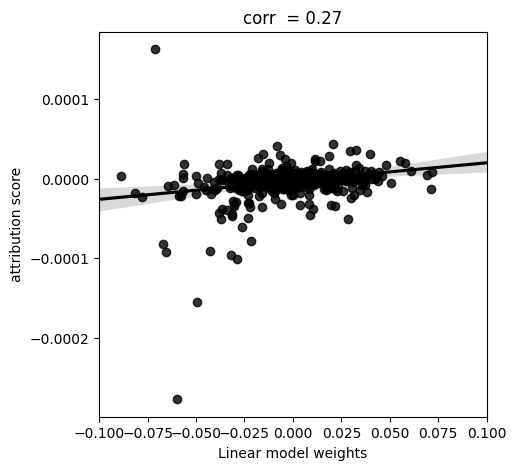

In [607]:
# correlation between attribution scores and linear model weights
weights = linear_model.model.coef_

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
sns.regplot(x=weights, y=mean_attribution[5,0,:], ax=ax, color='k')
ax.set_xlabel('Linear model weights')
ax.set_ylabel('attribution score')
ax.set_title(f'corr  = {np.corrcoef(weights, mean_attribution[5,0,:])[0,1]:.2f}')
ax.set_xlim([-0.1, 0.1])
plt.show()